## Setup -- test the connection to Claude via Bedrock

This notebook connects to Claude Sonnet through AWS Bedrock. Credentials come from a `.env` file at the repo root (copy `.env.example` to `.env` and fill in your AWS access key, secret key, and region).

Run the cell below -- it sends one tiny real request and prints PASS, or a specific, actionable error if something is misconfigured. This step is optional: the rest of this notebook runs entirely in simulation mode either way, so a failed or skipped connection test does not block anything below.

>> NOTE: This notebook is not that important. Can skip this

In [2]:
%pip install -r "../../../requirements.txt"

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached google_genai-2.17.0-py3-none-any.whl.metadata (56 kB)
  Using cached anthropic-0.120.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached boto3-1.43.65-py3-none-any.whl.metadata (6.6 kB)
  Using cached google_auth-2.56.3-py3-none-any.whl.metadata (6.0 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-50.0.0-cp311-abi3-macosx_11_0_arm64.whl.metadata (4.3 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached docstring_parser-0.18.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached botocore-1.4

## Test inference with boto3

In [1]:
import boto3
import json
import os
from dotenv import load_dotenv

load_dotenv()

client = boto3.client(
    "bedrock-runtime",
    region_name="us-east-1",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

request_body = {
    "anthropic_version": "bedrock-2023-05-31",
    "max_tokens": 20,
    "messages": [{"role": "user", "content": "Reply with exactly the word: pong"}],
}

response = client.invoke_model(
    modelId="us.anthropic.claude-sonnet-4-5-20250929-v1:0",
    body=json.dumps(request_body),
)
response_body = json.loads(response["body"].read())

print("Response:", response_body["content"][0]["text"])
print("Usage:", response_body["usage"])


Response: pong
Usage: {'input_tokens': 15, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 5}


## Test with Manttle

In [2]:
import os
from dotenv import load_dotenv
import anthropic

load_dotenv()

client = anthropic.AnthropicBedrockMantle(
    aws_access_key=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    aws_region="us-east-1",
)

response = client.messages.create(
    model="anthropic.claude-sonnet-5",
    max_tokens=20,
    messages=[{"role": "user", "content": "Reply with exactly the word: pong"}],
)

print("Response:", response.content[0].text)
print("Usage:", response.usage)


Response: pong
Usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo=None, input_tokens=18, output_tokens=4, output_tokens_details=OutputTokensDetails(thinking_tokens=0), server_tool_use=None, service_tier='standard')


In [3]:
import os
from pathlib import Path

from dotenv import load_dotenv
import anthropic


def _find_and_load_env() -> None:
    """Walk up from the current working directory to find and load a repo-root .env file, if one exists."""
    here = Path.cwd()
    for parent in [here, *here.parents]:
        candidate = parent / ".env"
        if candidate.is_file():
            load_dotenv(candidate)
            return
    print("No .env file found -- copy .env.example to .env at the repo root to enable the real-model sections.")


_find_and_load_env()

AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
AWS_REGION = os.getenv("AWS_REGION", "ap-south-1")
MODEL_NAME = os.getenv("BEDROCK_MODEL_ID", "anthropic.claude-sonnet-5")

print("AWS region selected : ",AWS_REGION)


def test_connection(client, model_name):
    """Send a trivial ping to confirm the Bedrock connection actually works."""
    print(f"Testing connection to Bedrock (model={model_name})...")
    try:
        response = client.messages.create(
            model=model_name, max_tokens=10,
            messages=[{"role": "user", "content": "Reply with exactly the word: pong"}],
        )
        reply = next((b.text for b in response.content if b.type == "text"), "")
        status = "PASS" if "pong" in reply.lower() else f"unexpected reply: {reply!r}"
        print(f"  {status}")
    except Exception as exc:
        print(f"  Connection check FAILED: {type(exc).__name__}: {exc}")
        print()
        print("The rest of this notebook still works fully in simulation mode --")
        print("this cell only matters for the optional real-API section later on.")


if not AWS_ACCESS_KEY_ID or not AWS_SECRET_ACCESS_KEY:
    print("AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY not set in .env -- skipping connection test.")
    print("The rest of this notebook still works fully in simulation mode.")
else:
    client = anthropic.AnthropicBedrockMantle(
        aws_access_key=AWS_ACCESS_KEY_ID, aws_secret_key=AWS_SECRET_ACCESS_KEY, aws_region=AWS_REGION,
    )
    test_connection(client, MODEL_NAME)


AWS region selected :  us-east-1
Testing connection to Bedrock (model=anthropic.claude-sonnet-5)...
  PASS


## Quick Test -- Bedrock + Claude Sonnet Connection

A minimal, standalone check that Bedrock access actually works: one real API call, independent of the setup cell above. Reads your AWS credentials and model name from `.env` and prints the model's reply.

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
import anthropic

for _parent in [Path.cwd(), *Path.cwd().parents]:
    if (_parent / ".env").is_file():
        load_dotenv(_parent / ".env")
        break

BEDROCK_AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
BEDROCK_AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
BEDROCK_AWS_REGION = os.getenv("AWS_REGION", "ap-south-1")
BEDROCK_MODEL_NAME = os.getenv("BEDROCK_MODEL_ID", "anthropic.claude-sonnet-5")

bedrock_client = anthropic.AnthropicBedrockMantle(
    aws_access_key=BEDROCK_AWS_ACCESS_KEY_ID,
    aws_secret_key=BEDROCK_AWS_SECRET_ACCESS_KEY,
    aws_region=BEDROCK_AWS_REGION,
)

response = bedrock_client.messages.create(
    model=BEDROCK_MODEL_NAME,
    max_tokens=20,
    messages=[{"role": "user", "content": "Reply with exactly the word: pong"}],
)

print(f"Model:    {BEDROCK_MODEL_NAME}")
print(f"Response: {response.content[0].text}")
print(f"Usage:    {response.usage}")


# Chapter 1 -- The 2026 Agent Landscape (Practice)

Work through this notebook **after reading** `notes/ch01-agent-landscape.md`, especially Section 11's dry-run. Two exercises below have a stub for you to fill in, each followed by a **verification cell** you run to grade yourself. Everything else (config, plotting, the optional real-API comparison) is given and fully working.

This notebook reproduces Section 11's hand computation in code: instrumenting one 15-step agent-loop call, tracking how the fixed prefix (system prompt + tool schemas) and the growing conversation tail separately drive cost, with and without prompt caching.

In [2]:
# ============================================================
# TOPIC: Instrumenting a single agent-loop call -- token growth
#        and prompt-caching economics across a 15-step loop
# MATH:  prefill_k = fixed_prefix + (k - 1) * (completion + observation)
# REF:   B04-AI_Agents notes/ch01-agent-landscape.md, Section 11
# ============================================================

# --- Imports (stdlib -> third-party -> local) ---
import os
from dataclasses import dataclass
from typing import List, Dict

import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Load secrets from a local .env file (never committed -- see .env.example
# at the repo root). Safe to call even if .env does not exist yet.
load_dotenv()

# --- Constants / Config ---
# The exact scenario walked through by hand in notes Section 11.
# Nothing here is random -- the goal is to reproduce that hand
# arithmetic in code, then push past it with a real plot.

SYSTEM_PROMPT_TOKENS = 3_000     # durable instructions, sent every call
NUM_TOOLS = 6                    # tool schemas exposed to the model
TOOL_SCHEMA_TOKENS_EACH = 200    # ~200 tokens per tool schema (Ch 3 territory)
OBSERVATION_TOKENS_AVG = 800     # average tool-result size fed back in
COMPLETION_TOKENS_AVG = 150      # average thought-plus-tool-call the model emits
N_STEPS = 15                     # length of the agent loop (Ch 2's mini-agent)

FIXED_PREFIX_TOKENS = SYSTEM_PROMPT_TOKENS + NUM_TOOLS * TOOL_SCHEMA_TOKENS_EACH
TURN_GROWTH_TOKENS = COMPLETION_TOKENS_AVG + OBSERVATION_TOKENS_AVG

print('=' * 60)
print('CONFIG: one agent-loop run')
print('=' * 60)
print(f'  Fixed prefix (system + {NUM_TOOLS} tool schemas): {FIXED_PREFIX_TOKENS:,} tokens')
print(f'  Growth per step (completion + observation):        {TURN_GROWTH_TOKENS:,} tokens')
print(f'  Loop length:                                       {N_STEPS} steps')


CONFIG: one agent-loop run
  Fixed prefix (system + 6 tool schemas): 4,200 tokens
  Growth per step (completion + observation):        950 tokens
  Loop length:                                       15 steps


In [3]:
# --- Pricing (illustrative Sonnet-class rates, matching the notes) ---
# ALWAYS check current published rates before using these for a real
# budget -- prices change. These are the exact figures notes Section 11 uses.

INPUT_PRICE_PER_M_TOKENS = 3.00    # dollars per 1,000,000 input tokens (no cache)
OUTPUT_PRICE_PER_M_TOKENS = 15.00  # dollars per 1,000,000 output tokens
CACHE_WRITE_MULTIPLIER = 1.25      # 5-minute cache write
CACHE_READ_MULTIPLIER = 0.10       # cache read = 90 percent discount

CACHE_WRITE_PRICE_PER_M_TOKENS = INPUT_PRICE_PER_M_TOKENS * CACHE_WRITE_MULTIPLIER
CACHE_READ_PRICE_PER_M_TOKENS = INPUT_PRICE_PER_M_TOKENS * CACHE_READ_MULTIPLIER


def usd(tokens: float, price_per_m: float) -> float:
    '''
    Convert a token count into a dollar cost at a given per-million-token rate.
    Args: tokens -- number of tokens billed. price_per_m -- USD per 1,000,000 tokens.
    Returns: cost in USD.
    Math: cost = tokens * (price_per_m / 1_000_000)
    '''
    return tokens * (price_per_m / 1_000_000)


print(f'  Standard input:  ${INPUT_PRICE_PER_M_TOKENS:.2f} / 1M tokens')
print(f'  Cache write:     ${CACHE_WRITE_PRICE_PER_M_TOKENS:.2f} / 1M tokens (1.25x)')
print(f'  Cache read:      ${CACHE_READ_PRICE_PER_M_TOKENS:.2f} / 1M tokens (0.10x)')
print(f'  Output:          ${OUTPUT_PRICE_PER_M_TOKENS:.2f} / 1M tokens')


  Standard input:  $3.00 / 1M tokens
  Cache write:     $3.75 / 1M tokens (1.25x)
  Cache read:      $0.30 / 1M tokens (0.10x)
  Output:          $15.00 / 1M tokens


## Exercise 1 -- Implement the cached-cost branch of `simulate_step`

The stub below already computes, for step `k`: the fixed-prefix tokens, the growing-tail tokens, the total prefill, and `cost_no_cache` (everything priced at the standard input rate). Your job is to fill in `cost_with_cache` following notes Section 11's logic exactly:

- On **step 1**, the fixed prefix has never been seen before, so it is a **cache WRITE** (priced at `CACHE_WRITE_PRICE_PER_M_TOKENS`).
- On **every step after that**, the fixed prefix is a **cache READ** (priced at `CACHE_READ_PRICE_PER_M_TOKENS`).
- The growing tail is **never cacheable** -- it changes every step -- so it always costs the standard input rate.
- Do not forget the completion tokens, priced at the output rate, in both branches.

Replace the `# TODO` block inside `simulate_step` below.

In [4]:
@dataclass
class StepRecord:
    '''One agent-loop step token and cost breakdown.'''
    step: int
    fixed_prefix_tokens: int
    tail_tokens: int
    prefill_tokens: int
    completion_tokens: int
    cost_no_cache: float
    cost_with_cache: float
    cache_event: str  # 'WRITE' or 'READ'


def simulate_step(step: int) -> StepRecord:
    '''
    Compute the token and cost breakdown for step `step` (1-indexed) of
    the N_STEPS-long agent loop, matching notes Section 11's derivation:
    prefill_k = FIXED_PREFIX_TOKENS + (k - 1) * TURN_GROWTH_TOKENS.
    '''
    prior_turns = step - 1
    tail_tokens = prior_turns * TURN_GROWTH_TOKENS
    prefill_tokens = FIXED_PREFIX_TOKENS + tail_tokens

    # --- cost WITHOUT caching: everything at the standard input rate (given) ---
    cost_no_cache = (
        usd(prefill_tokens, INPUT_PRICE_PER_M_TOKENS)
        + usd(COMPLETION_TOKENS_AVG, OUTPUT_PRICE_PER_M_TOKENS)
    )

    # --- cost WITH caching: TODO -- fill this in ---
    # cache_event = 'WRITE' if step == 1 else 'READ'
    # prefix_cost = ... (use CACHE_WRITE_PRICE_PER_M_TOKENS on step 1,
    #                     CACHE_READ_PRICE_PER_M_TOKENS otherwise)
    # tail_cost = ... (tail_tokens are NEVER cacheable -- standard input rate)
    # cost_with_cache = prefix_cost + tail_cost + (completion at output rate)
    cache_event = 'WRITE' if step == 1 else 'READ'                    # 1. first sighting writes, every repeat reads
    prefix_price = (
        CACHE_WRITE_PRICE_PER_M_TOKENS if step == 1
        else CACHE_READ_PRICE_PER_M_TOKENS
    )
    prefix_cost = usd(FIXED_PREFIX_TOKENS, prefix_price)               # 2. only the fixed prefix is ever cacheable
    tail_cost = usd(tail_tokens, INPUT_PRICE_PER_M_TOKENS)              # 3. tail changes every step -- never cached
    cost_with_cache = (
        prefix_cost + tail_cost + usd(COMPLETION_TOKENS_AVG, OUTPUT_PRICE_PER_M_TOKENS)
    )  

    return StepRecord(
        step=step,
        fixed_prefix_tokens=FIXED_PREFIX_TOKENS,
        tail_tokens=tail_tokens,
        prefill_tokens=prefill_tokens,
        completion_tokens=COMPLETION_TOKENS_AVG,
        cost_no_cache=cost_no_cache,
        cost_with_cache=cost_with_cache,
        cache_event=cache_event,
    )


**Verification -- Exercise 1**

Run the full 15-step loop through your `simulate_step` and check the totals against notes Section 11's hand-derived numbers.

In [5]:
print('=' * 60)
print('RUNNING THE 15-STEP AGENT LOOP (simulated)')
print('=' * 60)

records: List[StepRecord] = []
cumulative_no_cache = 0.0
cumulative_with_cache = 0.0

for k in range(1, N_STEPS + 1):
    rec = simulate_step(k)
    records.append(rec)
    cumulative_no_cache += rec.cost_no_cache
    cumulative_with_cache += rec.cost_with_cache

    print(f'\nSTEP {rec.step:2d} | cache {str(rec.cache_event):5s} | '
          f'prefill={rec.prefill_tokens:6,} tok '
          f'(prefix={rec.fixed_prefix_tokens:,} + tail={rec.tail_tokens:,}) | '
          f'completion={rec.completion_tokens} tok')
    print(f'         no-cache step cost=${rec.cost_no_cache:.6f} | '
          f'with-cache step cost=${rec.cost_with_cache:.6f}')
    print(f'         cumulative: no-cache=${cumulative_no_cache:.4f} | '
          f'with-cache=${cumulative_with_cache:.4f}')

total_prefill_tokens = sum(r.prefill_tokens for r in records)
total_completion_tokens = sum(r.completion_tokens for r in records)

print('\n' + '=' * 60)
print('SUMMARY -- 15-step run')
print('=' * 60)
print(f'  Total prefill tokens processed:  {total_prefill_tokens:,}')
print(f'  Total completion tokens:         {total_completion_tokens:,}')
print(f'  Total cost WITHOUT caching:      ${cumulative_no_cache:.4f}')
print(f'  Total cost WITH caching:         ${cumulative_with_cache:.4f}')

# --- Cross-check against the hand computation in notes Section 11 ---
EXPECTED_TOTAL_PREFILL = 162_750
EXPECTED_NO_CACHE_COST = 0.522
EXPECTED_WITH_CACHE_COST = 0.36639

assert total_prefill_tokens == EXPECTED_TOTAL_PREFILL, 'Prefill token total drifted from the notes derivation.'
assert abs(cumulative_no_cache - EXPECTED_NO_CACHE_COST) < 0.001, 'No-cache cost drifted from the notes.'
assert abs(cumulative_with_cache - EXPECTED_WITH_CACHE_COST) < 0.001, 'Cached cost drifted from the notes -- check your Exercise 1 branch.'
print('\nPASS -- matches the hand-derived arithmetic in notes/ch01-agent-landscape.md Section 11 exactly.')


RUNNING THE 15-STEP AGENT LOOP (simulated)

STEP  1 | cache WRITE | prefill= 4,200 tok (prefix=4,200 + tail=0) | completion=150 tok
         no-cache step cost=$0.014850 | with-cache step cost=$0.018000
         cumulative: no-cache=$0.0149 | with-cache=$0.0180

STEP  2 | cache READ  | prefill= 5,150 tok (prefix=4,200 + tail=950) | completion=150 tok
         no-cache step cost=$0.017700 | with-cache step cost=$0.006360
         cumulative: no-cache=$0.0326 | with-cache=$0.0244

STEP  3 | cache READ  | prefill= 6,100 tok (prefix=4,200 + tail=1,900) | completion=150 tok
         no-cache step cost=$0.020550 | with-cache step cost=$0.009210
         cumulative: no-cache=$0.0531 | with-cache=$0.0336

STEP  4 | cache READ  | prefill= 7,050 tok (prefix=4,200 + tail=2,850) | completion=150 tok
         no-cache step cost=$0.023400 | with-cache step cost=$0.012060
         cumulative: no-cache=$0.0765 | with-cache=$0.0456

STEP  5 | cache READ  | prefill= 8,000 tok (prefix=4,200 + tail=3,800)

## Exercise 2 -- Why does not caching save close to 90 percent?

Cache reads are a 90 percent discount. Yet the full-run savings you just measured are nowhere near 90 percent. Compute `savings_pct` below from the two totals you already have, then write one sentence in `my_explanation` naming which part of the context the 90 percent discount can never touch.

In [6]:
# TODO: compute the percentage saved by caching, using the two totals above
savings_pct = (cumulative_no_cache - cumulative_with_cache) / cumulative_no_cache * 100  # TODO: (cumulative_no_cache - cumulative_with_cache) / cumulative_no_cache * 100

# TODO: one sentence -- which part of the context can the cache discount never reach?
my_explanation = (
    'The 90 percent cache discount only ever applies to the fixed prefix '
    '(system prompt + tool schemas); the growing conversation tail changes '
    'every step, so it can never hit a cache and it is what dominates the '
    'total bill on a long run.'
)


**Verification -- Exercise 2**

In [7]:
assert savings_pct is not None, 'Fill in savings_pct first.'
assert 20 < savings_pct < 40, f'Expected roughly 25 to 35 percent savings, got {savings_pct:.1f} percent -- recheck the formula.'
assert len(my_explanation.strip()) > 0, 'Write your one-sentence explanation in my_explanation.'
print(f'PASS -- caching saved {savings_pct:.1f} percent on this run.')
print(f'Your explanation: {my_explanation}')
print('\n(Compare against notes Section 11: the growing, uncacheable tail')
print('dominates the bill, so an 84 percent discount on the fixed prefix alone')
print('only becomes a roughly 30 percent discount on the whole run.)')


PASS -- caching saved 29.8 percent on this run.
Your explanation: The 90 percent cache discount only ever applies to the fixed prefix (system prompt + tool schemas); the growing conversation tail changes every step, so it can never hit a cache and it is what dominates the total bill on a long run.

(Compare against notes Section 11: the growing, uncacheable tail
dominates the bill, so an 84 percent discount on the fixed prefix alone
only becomes a roughly 30 percent discount on the whole run.)


### Everything below this line is given -- no exercises

A plot of cumulative cost, with and without caching, across all 15 steps.

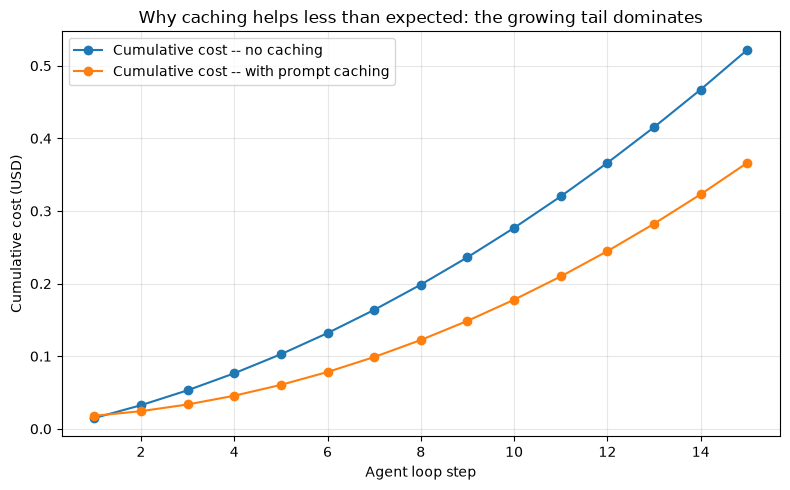


Notice the two lines are roughly PARALLEL after the first couple of
steps, not converging -- caching gives a one-time discount on the
fixed prefix, but both lines keep climbing at almost the same rate,
driven by the uncacheable growing tail. This is the arithmetic
argument for context management, covered in Chapter 4, not just a caching tip.


In [8]:
steps = [r.step for r in records]
cum_no_cache, cum_cache = [], []
running_no, running_yes = 0.0, 0.0
for r in records:
    running_no += r.cost_no_cache
    running_yes += r.cost_with_cache
    cum_no_cache.append(running_no)
    cum_cache.append(running_yes)

plt.figure(figsize=(8, 5))
plt.plot(steps, cum_no_cache, marker='o', label='Cumulative cost -- no caching')
plt.plot(steps, cum_cache, marker='o', label='Cumulative cost -- with prompt caching')
plt.xlabel('Agent loop step')
plt.ylabel('Cumulative cost (USD)')
plt.title('Why caching helps less than expected: the growing tail dominates')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ch01_cost_growth.png', dpi=120)
plt.show()

print('\nNotice the two lines are roughly PARALLEL after the first couple of')
print('steps, not converging -- caching gives a one-time discount on the')
print('fixed prefix, but both lines keep climbing at almost the same rate,')
print('driven by the uncacheable growing tail. This is the arithmetic')
print('argument for context management, covered in Chapter 4, not just a caching tip.')


### Optional -- compare against REAL numbers from Bedrock + Claude Sonnet

This section is a system-boundary check: it runs a few real steps against Claude Sonnet through AWS Bedrock and prints the ACTUAL measured `cache_creation_input_tokens` / `cache_read_input_tokens` from the response, so you can compare real numbers to the simulated ones above. It's guarded so the notebook runs top-to-bottom cleanly even without AWS credentials configured -- flip `RUN_REAL_API_DEMO` to `True` once your `.env` is filled in.

In [ ]:
RUN_REAL_API_DEMO = False
REAL_DEMO_STEPS = 2  # keep small -- this costs real money


def run_real_api_demo(n_steps: int = REAL_DEMO_STEPS) -> None:
    """
    Reproduce a few steps of the same growing-conversation scenario against
    Claude Sonnet via AWS Bedrock, printing ACTUAL usage.input_tokens,
    cache_creation_input_tokens, and cache_read_input_tokens from the
    response, so you can compare measured numbers to the simulation above.
    """
    aws_access_key = os.getenv("AWS_ACCESS_KEY_ID")
    aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
    aws_region = os.getenv("AWS_REGION", "ap-south-1")
    model_name = os.getenv("BEDROCK_MODEL_ID", "anthropic.claude-sonnet-5")

    if not aws_access_key or not aws_secret_key:
        print("Skipping real API demo: AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY not set in .env.")
        print("Copy .env.example to .env at the repo root and fill it in, then re-run this cell.")
        return

    import anthropic
    client = anthropic.AnthropicBedrockMantle(
        aws_access_key=aws_access_key, aws_secret_key=aws_secret_key, aws_region=aws_region,
    )

    # Prompt caching has a per-model MINIMUM cacheable length -- below it,
    # cache_creation_input_tokens and cache_read_input_tokens both read 0
    # even though cache_control was set. Claude Sonnet 5's minimum is 1,024
    # tokens, so the padding below is sized to clear that comfortably.
    system_block = [{
        "type": "text",
        "text": "You are a terse test agent. " * 300,  # comfortably over the 1,024-token minimum
        "cache_control": {"type": "ephemeral"},
    }]
    messages: List[Dict] = []

    print("=" * 60)
    print(f"RUNNING {n_steps} REAL STEPS AGAINST CLAUDE SONNET VIA BEDROCK")
    print("=" * 60)

    for k in range(1, n_steps + 1):
        messages.append({"role": "user", "content": f"Step {k}: continue the task in one short sentence."})
        try:
            response = client.messages.create(
                model=model_name, max_tokens=50, system=system_block, messages=messages,
            )
        except Exception as exc:
            print(f"STEP {k} FAILED: {type(exc).__name__}: {exc}")
            return

        usage = response.usage
        messages.append({"role": "assistant", "content": response.content[0].text})

        cache_creation = getattr(usage, "cache_creation_input_tokens", 0)
        cache_read = getattr(usage, "cache_read_input_tokens", 0)
        print(f"\nSTEP {k} (REAL) | input_tokens={usage.input_tokens} | "
              f"cache_creation={cache_creation} | cache_read={cache_read} | "
              f"output_tokens={usage.output_tokens}")
        if cache_creation == 0 and cache_read == 0 and k > 1:
            print("         (both cache fields are 0 -- system_block may be under the minimum cacheable length)")


if RUN_REAL_API_DEMO:
    run_real_api_demo()
else:
    print("RUN_REAL_API_DEMO is False -- running in simulation-only mode.")
    print("Flip it to True (with AWS credentials set in .env) to see real measured")
    print("cache_creation_input_tokens and cache_read_input_tokens from Bedrock")
    print("instead of the simulated numbers above.")


## Key Takeaways

A 15-step agent loop processes over 160,000 prefill tokens because the whole transcript resends every step. Prompt caching gives a real discount, but only on the stable fixed prefix -- the growing conversation tail can never be cached, and it is what actually dominates the bill on a real run. That is the arithmetic case for Chapter 4's context management: caching is a discount on repetition, not a cure for growth.

**Connection forward:** `ch02` stops talking about the loop and writes one -- a real, working agent in plain Python, no framework.